In [17]:
# Created a conda environment 
# conda install -c conda-forge swig box2d-py
# Python version 3.10.18

In [ ]:
#! pip install gymnasium[box2d]
#! pip install pygame
#! pip install tqdm
#! pip install seaborn
#! pip install matplotlib
#! pip install numpy
#! pip install torch

: 

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
from collections import deque
import os
from stable_baselines3 import PPO
from torch.distributions import Normal
from torch.optim import Adam

In [35]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
ENV =  gym.make("LunarLander-v3", continuous=True, gravity=-10.0,
               enable_wind=True, wind_power=15.0, turbulence_power=1.5, render_mode="rgb_array")

In [38]:
print("Observation space ", ENV.observation_space)

Observation space  Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)


In [39]:
print("Action Space Shape", ENV.action_space)

Action Space Shape Box(-1.0, 1.0, (2,), float32)


In [40]:
ENV.reset(seed=SEED)
ENV.action_space.seed(SEED)
ENV.observation_space.seed(SEED)

42

In [41]:
obs_dim = ENV.observation_space.shape[0]
act_dim = ENV.action_space.shape[0]
act_limit = float(ENV.action_space.high[0])


In [48]:
# Define the Actor-Critic Network
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(ActorCritic, self).__init__()
        # Shared layers
        self.base = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )
        # Actor head
        self.mu_head = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))  # learnable log_std
        # Critic head
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, state):
        x = self.base(state)
        mu = self.mu_head(x)
        std = torch.exp(self.log_std)
        value = self.value_head(x)
        return mu, std, value

    def get_action(self, state):
        mu, std, _ = self.forward(state)
        dist = Normal(mu, std)
        action = dist.sample()
        return action.clamp(-1, 1), dist.log_prob(action).sum(dim=-1)

    def evaluate(self, state, action):
        mu, std, value = self.forward(state)
        dist = Normal(mu, std)
        log_prob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return log_prob, entropy, value.squeeze(-1)

# Define the PPO agent
class PPOAgent:
    def __init__(self, env, gamma=0.99, clip_eps=0.2, lam=0.95, epochs=10, batch_size=64, lr=3e-4):
        self.env = env
        self.gamma = gamma
        self.clip_eps = clip_eps
        self.lam = lam
        self.epochs = epochs
        self.batch_size = batch_size

        self.model = ActorCritic(env.observation_space.shape[0], env.action_space.shape[0])
        self.optimizer = Adam(self.model.parameters(), lr=lr)

    def compute_gae(self, rewards, values, dones):
        gae = 0
        returns = []
        values = values + [0]  # bootstrap value
        for step in reversed(range(len(rewards))):
            delta = rewards[step] + self.gamma * values[step + 1] * (1 - dones[step]) - values[step]
            gae = delta + self.gamma * self.lam * (1 - dones[step]) * gae
            returns.insert(0, gae + values[step])
        return returns

    def update(self, states, actions, old_log_probs, returns, advantages):
        states = torch.FloatTensor(states)
        actions = torch.FloatTensor(actions)
        old_log_probs = torch.FloatTensor(old_log_probs)
        returns = torch.FloatTensor(returns)
        advantages = torch.FloatTensor(advantages)

        for _ in range(self.epochs):
            indices = np.arange(len(states))
            np.random.shuffle(indices)
            for i in range(0, len(states), self.batch_size):
                idx = indices[i:i+self.batch_size]
                log_probs, entropy, values = self.model.evaluate(states[idx], actions[idx])
                ratio = torch.exp(log_probs - old_log_probs[idx])
                surr1 = ratio * advantages[idx]
                surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * advantages[idx]
                actor_loss = -torch.min(surr1, surr2).mean()
                critic_loss = (returns[idx] - values).pow(2).mean()
                loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy.mean()

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

    def train(self, total_timesteps=200000):
        state, _ = self.env.reset()
        memory = []
        rewards, values, dones = [], [], []
        total_steps = 0
        episode_reward = 0
        reward_history = []

        while total_steps < total_timesteps:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            action, log_prob = self.model.get_action(state_tensor)
            next_state, reward, terminated, truncated, _ = self.env.step(action.detach().numpy()[0])
            done = terminated or truncated

            _, _, value = self.model.forward(state_tensor)
            memory.append((state, action.detach().numpy(), log_prob.item(), reward, done, value.item()))
            state = next_state
            total_steps += 1
            episode_reward += reward

            if done:
                states, actions, log_probs, rewards_, dones_, values_ = zip(*memory)
                returns = self.compute_gae(rewards_, list(values_), dones_)
                advantages = np.array(returns) - np.array(values_)
                self.update(states, actions, log_probs, returns, advantages)
                reward_history.append(episode_reward)
                print(f"Episode {len(reward_history)} reward: {episode_reward}")
                memory.clear()
                episode_reward = 0
                state, _ = self.env.reset()

        # Save model
        torch.save(self.model.state_dict(), "ppo_lunarlander_final.pt")

        # Generate plots
  
        return reward_history

    def plot_rewards(self, reward_history):
        plt.figure(figsize=(10, 5))
        plt.plot(reward_history, alpha=0.3, label="Raw reward")
        if len(reward_history) >= 100:
            smoothed = np.convolve(reward_history, np.ones(100)/100, mode='valid')
            plt.plot(range(99, len(reward_history)), smoothed, label="100-ep moving avg", color='red')
        plt.axhline(200, linestyle="--", color="green", label="Solved")
        plt.xlabel("Episode")
        plt.ylabel("Total Reward")
        plt.title("PPO on LunarLander-v3 (Shaped Reward, Episode-based)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("ppo_lunarlander_final.png")
        plt.show()

        # Episode Rewards
        plt.figure(figsize=(8, 4))
        plt.hist(reward_history[-500:], bins=40, color='skyblue', edgecolor='black')
        plt.title("Reward Distribution (Last 500 Episodes)")
        plt.xlabel("Episode Reward")
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("ppo_lunarlander_histogram.png")
        plt.show()

        # === Reward Std Dev Plot ===
        # Use a moving window to compute standard deviation of rewards over time
        window = 100  # Size of the moving window

        # Ensure we have enough episodes
        if len(reward_history) >= window:
            # Compute rolling standard deviation
            rolling_std = [np.std(reward_history[i - window:i]) for i in range(window, len(reward_history))]

            # === Plot the rolling standard deviation ===
            plt.figure(figsize=(10, 4))
            plt.plot(range(window, len(reward_history)), rolling_std)  # X-axis is episode number
            plt.title("Reward Std Dev (Moving Window of 100 Episodes)")
            plt.xlabel("Episode")
            plt.ylabel("Std Dev")
            plt.grid(True)
            plt.tight_layout()
            plt.savefig("ppo_lunarlander_stddev.png")
            plt.show()
        else:
            print(f"Not enough episodes to compute rolling std (need at least {window}, have {len(reward_history)})")

In [49]:
agent = PPOAgent(ENV)

Episode 1 reward: -507.2140654981871
Episode 2 reward: -310.7467832797495
Episode 3 reward: -495.40685589871566
Episode 4 reward: -508.5574927383517
Episode 5 reward: -863.2088640513241
Episode 6 reward: -428.38797254203104
Episode 7 reward: -740.6504907212617
Episode 8 reward: -524.8659797431231
Episode 9 reward: -569.4532969092986
Episode 10 reward: -418.52058200284705
Episode 11 reward: -478.84701441308465
Episode 12 reward: -602.424457203528
Episode 13 reward: -470.6447266909037
Episode 14 reward: -483.1552601620707
Episode 15 reward: -664.2472337410999
Episode 16 reward: -797.5523051184988
Episode 17 reward: -804.6653196948276
Episode 18 reward: -835.6737827696618
Episode 19 reward: -711.1416908444481
Episode 20 reward: -488.21911278540887
Episode 21 reward: -467.3747567059568
Episode 22 reward: -398.7341762897428
Episode 23 reward: -797.1377935980329
Episode 24 reward: -387.2136172016157
Episode 25 reward: -517.6807167279908
Episode 26 reward: -443.1696329629729
Episode 27 reward

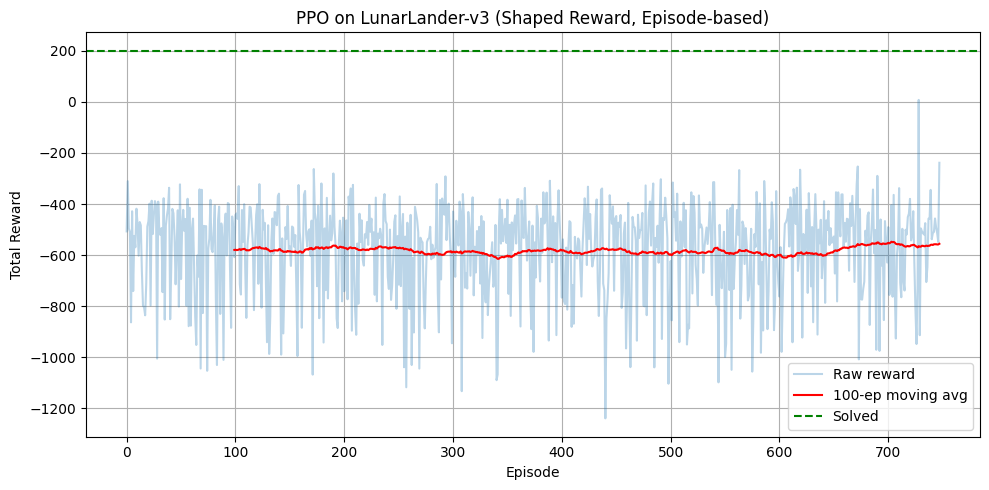

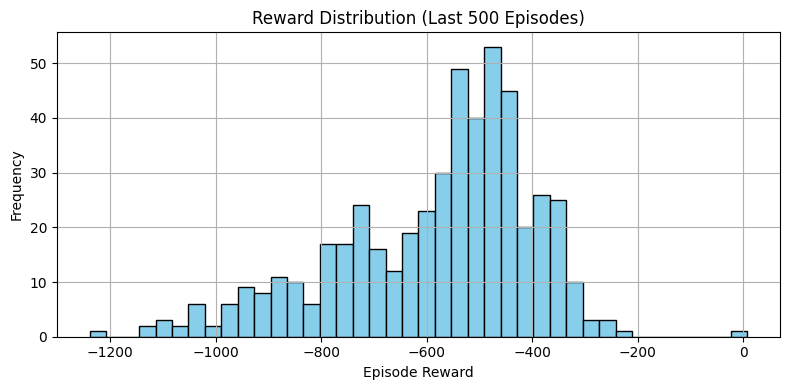

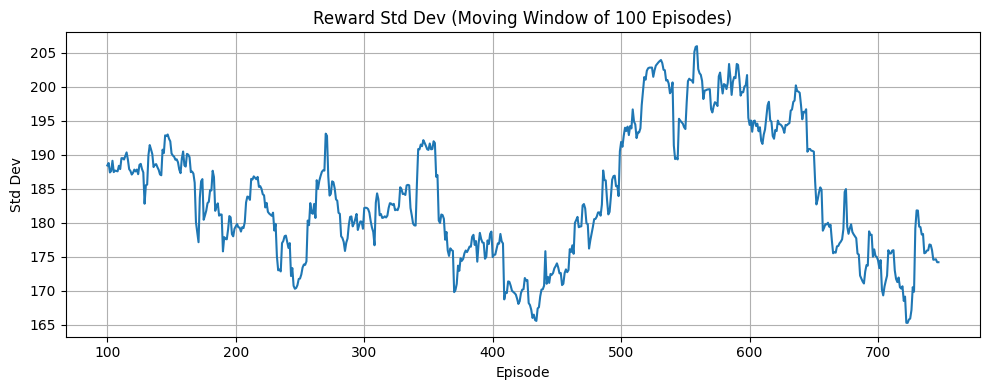

In [50]:
rewards = agent.train(50000)
agent.plot_rewards(rewards)

In [74]:
# === Evaluation Function ===
def evaluate(model, episodes=3):
    test_env = gym.make("LunarLander-v3", continuous=True, render_mode="human")
    for ep in range(episodes):
        obs, _ = test_env.reset()
        test_env.action_space.seed(SEED)
        total_reward = 0
        for _ in range(1000):
            with torch.no_grad():
                action, _ = model.model.get_action(torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device))
            obs, r, term, trunc, _ = test_env.step(action.cpu().numpy()[0])
            total_reward += r
            if term or trunc:
                break
        print(f"Eval Episode {ep+1}: Total Reward = {total_reward:.1f}")
    test_env.close()

In [75]:
evaluate(agent, 3)

Eval Episode 1: Total Reward = -853.7
Eval Episode 2: Total Reward = -578.3
Eval Episode 3: Total Reward = -473.5


SAC

In [58]:
obs_dim = ENV.observation_space.shape[0]
state_dim  = ENV.observation_space.shape[0]
action_dim = ENV.action_space.shape[0]
max_action = ENV.action_space.high[0]
act_limit = float(ENV.action_space.high[0])

In [59]:
state_dim

8

In [60]:
action_dim

2

In [ ]:
# Actor network: outputs mean and log_std for squashed Gaussian policy
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU()
        )
        self.mean = nn.Linear(256, action_dim)
        self.log_std = nn.Linear(256, action_dim)
        self.max_action = max_action

    def forward(self, state):
        x = self.fc(state)
        mean = self.mean(x)
        log_std = self.log_std(x).clamp(-20, 2)
        std = log_std.exp()
        return mean, std

    def sample(self, state):
        mean, std = self(state)
        dist = torch.distributions.Normal(mean, std)
        z = dist.rsample()
        action = torch.tanh(z)
        log_prob = dist.log_prob(z) - torch.log(1 - action.pow(2) + 1e-6)
        return action * self.max_action, log_prob.sum(1, keepdim=True)

# Critic network: Q-value estimation
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.q1 = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1)
        )
        self.q2 = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, state, action):
        x = torch.cat([state, action], 1)
        return self.q1(x), self.q2(x)

# Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity=int(1e6)):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return (
            torch.FloatTensor(state),
            torch.FloatTensor(action),
            torch.FloatTensor(reward).unsqueeze(1),
            torch.FloatTensor(next_state),
            torch.FloatTensor(done).unsqueeze(1)
        )

    def __len__(self):
        return len(self.buffer)

# SAC Agent
class SACAgent:
    def __init__(self, env):
        self.env = env
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.gamma = 0.99
        self.tau = 0.005
        self.alpha = 0.2
        self.batch_size = 256
        self.lr = 3e-4
        self.target_entropy = -env.action_space.shape[0]

        s_dim = env.observation_space.shape[0]
        a_dim = env.action_space.shape[0]
        self.max_action = float(env.action_space.high[0])

        self.actor = Actor(s_dim, a_dim, self.max_action).to(self.device)
        self.critic = Critic(s_dim, a_dim).to(self.device)
        self.critic_target = Critic(s_dim, a_dim).to(self.device)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.log_alpha = torch.tensor(np.log(self.alpha), requires_grad=True, device=self.device)
        self.actor_optim = Adam(self.actor.parameters(), lr=self.lr)
        self.critic_optim = Adam(self.critic.parameters(), lr=self.lr)
        self.alpha_optim = Adam([self.log_alpha], lr=self.lr)

        self.replay = ReplayBuffer()

    def update(self):
        if len(self.replay) < self.batch_size:
            return

        state, action, reward, next_state, done = self.replay.sample(self.batch_size)

        state = state.to(self.device)
        action = action.to(self.device)
        reward = reward.to(self.device)
        next_state = next_state.to(self.device)
        done = done.to(self.device)

        with torch.no_grad():
            next_action, next_log_prob = self.actor.sample(next_state)
            q1_next, q2_next = self.critic_target(next_state, next_action)
            q_target = reward + (1 - done) * self.gamma * (
                torch.min(q1_next, q2_next) - self.alpha * next_log_prob
            )

        q1, q2 = self.critic(state, action)
        critic_loss = F.mse_loss(q1, q_target) + F.mse_loss(q2, q_target)

        self.critic_optim.zero_grad()
        critic_loss.backward()
        self.critic_optim.step()

        new_action, log_prob = self.actor.sample(state)
        q1_pi, q2_pi = self.critic(state, new_action)
        actor_loss = (self.alpha * log_prob - torch.min(q1_pi, q2_pi)).mean()

        self.actor_optim.zero_grad()
        actor_loss.backward()
        self.actor_optim.step()

        alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
        self.alpha_optim.zero_grad()
        alpha_loss.backward()
        self.alpha_optim.step()
        self.alpha = self.log_alpha.exp()

        # Soft update
        for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - self.tau) + param.data * self.tau)

    def get_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        action, _ = self.actor.sample(state)
        return action.detach().cpu().numpy()[0]

    def train(self, total_steps=200_000, start_steps=10000):
        state, _ = self.env.reset()
        episode_reward = 0
        reward_history = []

        for step in range(total_steps):
            if step < start_steps:
                action = self.env.action_space.sample()
            else:
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                    action, _ = self.actor.sample(state_tensor)
                    action = action.cpu().numpy()[0]

            next_state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated
            self.replay.push(state, action, reward, next_state, float(done))

            state = next_state
            episode_reward += reward

            if done:
                reward_history.append(episode_reward)
                state, _ = self.env.reset()
                episode_reward = 0

            self.update()

            if (step + 1) % 1000 == 0:
                avg_reward = np.mean(reward_history[-100:]) if len(reward_history) >= 100 else np.mean(reward_history)
                print(f"Step {step + 1}, Avg Reward (last 100): {avg_reward:.2f}")

        return reward_history
    
    def plot_rewards(self, reward_history):
        plt.figure(figsize=(10, 5))
        plt.plot(reward_history, alpha=0.3, label="Raw reward")
        if len(reward_history) >= 100:
            smoothed = np.convolve(reward_history, np.ones(100) / 100, mode='valid')
            plt.plot(range(99, len(reward_history)), smoothed, label="100-ep moving avg", color='red')
        plt.axhline(200, linestyle="--", color="green", label="Solved")
        plt.xlabel("Episode")
        plt.ylabel("Total Reward")
        plt.title("SAC on LunarLander-v3")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("sac_lunarlander_final.png")
        plt.show()

        # Episode Rewards
        plt.figure(figsize=(8, 4))
        plt.hist(reward_history[-500:], bins=40, color='skyblue', edgecolor='black')
        plt.title("Reward Distribution (Last 500 Episodes)")
        plt.xlabel("Episode Reward")
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("ppo_lunarlander_histogram.png")
        plt.show()

        # === Rolling Std Dev Plot ===
        if len(reward_history) >= 100:
            window = 100
            rolling_std = [np.std(reward_history[i - window:i]) for i in range(window, len(reward_history))]
            plt.figure(figsize=(10, 4))
            plt.plot(range(window, len(reward_history)), rolling_std)
            plt.title("Reward Std Dev (Moving Window of 100 Episodes)")
            plt.xlabel("Episode")
            plt.ylabel("Std Dev")
            plt.grid(True)
            plt.tight_layout()
            plt.savefig("sac_lunarlander_stddev.png")
            plt.show()


In [62]:
obs, _ = ENV.reset()
episode_reward = 0
all_rewards = []

In [63]:
sac_agent = SACAgent(ENV)
rewards = sac_agent.train(total_steps=200000, start_steps=10000)

Step 1000, Avg Reward (last 100): -358.20
Step 2000, Avg Reward (last 100): -395.09
Step 3000, Avg Reward (last 100): -360.30
Step 4000, Avg Reward (last 100): -378.17
Step 5000, Avg Reward (last 100): -340.22
Step 6000, Avg Reward (last 100): -336.57
Step 7000, Avg Reward (last 100): -338.50
Step 8000, Avg Reward (last 100): -341.25
Step 9000, Avg Reward (last 100): -339.54
Step 10000, Avg Reward (last 100): -337.53
Step 11000, Avg Reward (last 100): -333.81
Step 12000, Avg Reward (last 100): -325.85
Step 13000, Avg Reward (last 100): -320.20
Step 14000, Avg Reward (last 100): -317.02
Step 15000, Avg Reward (last 100): -312.13
Step 16000, Avg Reward (last 100): -302.99
Step 17000, Avg Reward (last 100): -300.87
Step 18000, Avg Reward (last 100): -293.80
Step 19000, Avg Reward (last 100): -286.26
Step 20000, Avg Reward (last 100): -277.89
Step 21000, Avg Reward (last 100): -272.87
Step 22000, Avg Reward (last 100): -267.37
Step 23000, Avg Reward (last 100): -263.66
Step 24000, Avg Rewa

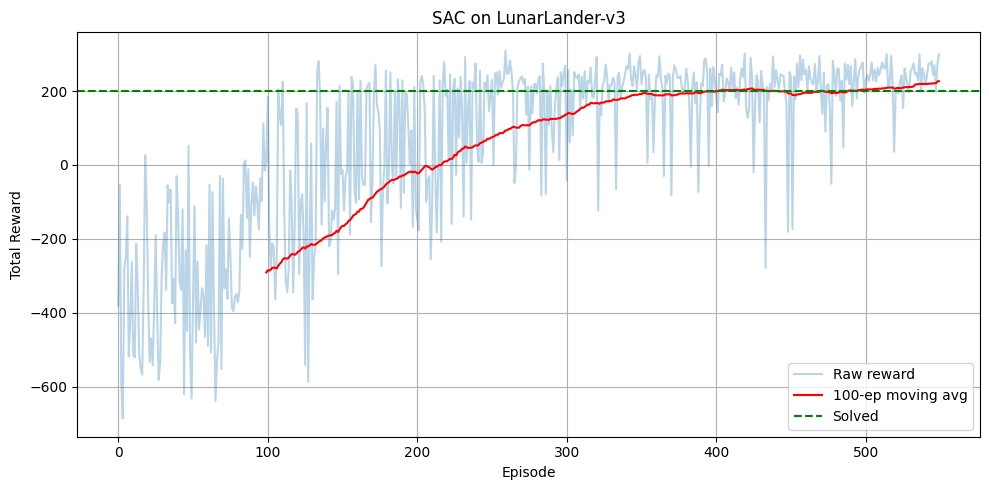

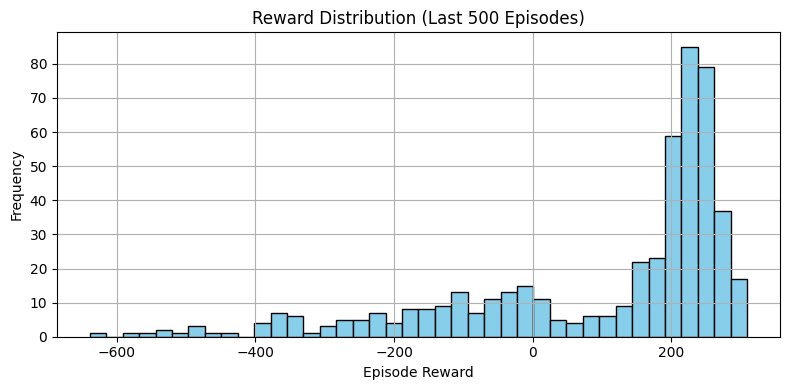

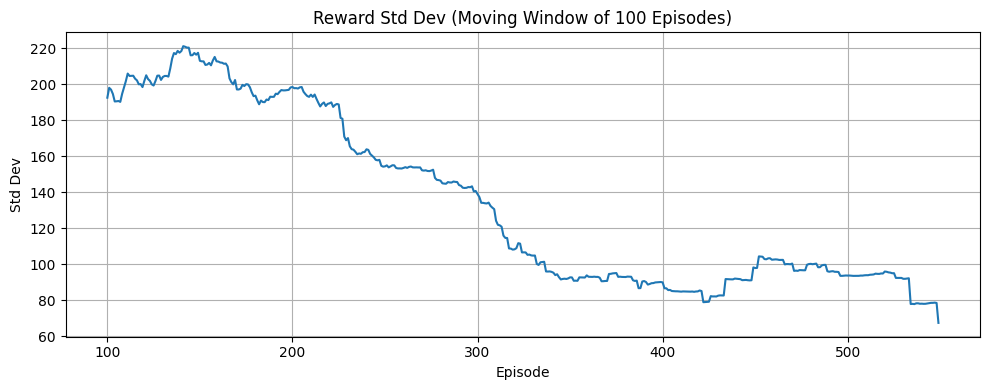

In [64]:
sac_agent.plot_rewards(rewards)

In [79]:
def evaluate_sac(model, episodes=3):
    test_env = gym.make("LunarLander-v3", continuous=True, render_mode="human")
    for ep in range(episodes):
        obs, _ = test_env.reset()
        total_reward = 0
        for _ in range(1000):
            with torch.no_grad():
                action = model.get_action(obs)
            obs, r, term, trunc, _ = test_env.step(action)
            total_reward += r
            if term or trunc:
                break
        print(f"Eval Episode {ep+1}: Total Reward = {total_reward:.1f}")
    test_env.close()


In [ ]:
evaluate_sac(sac_agent)

AttributeError: 'SACAgent' object has no attribute 'get_action'

: 

In [ ]:
torch.save(agent.actor.state_dict(), "sac_actor.pt")
torch.save(agent.critic.state_dict(), "sac_critic.pt")